In [71]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from joblib import Parallel, delayed
from datatools import *
import matplotlib.pyplot as plt

In [89]:
all_sample = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/all_sample.parquet')

In [ ]:
factor1 = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/cne6_factor.parquet')
factor2 = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/other_factor.parquet')
factor3 = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/tech_factor.parquet')

In [94]:
sample = all_sample.query( 'trade_date >= "2023-01-01"') ## oot
#sample = all_sample.query( 'trade_date < "2023-01-01"') # train
sample = sample.merge(factor1, on=['ts_code', 'trade_date'], how='left').merge(
    factor2, on=['ts_code', 'trade_date'], how='left').merge(factor3, on=['ts_code', 'trade_date'], how='left')

In [ ]:
factor = sample.copy()
ind = pd.read_csv('C:/Users/User/OneDrive - CUHK-Shenzhen/data/industry.csv')
factor = factor.merge(ind[['ts_code', 'l1_name']], on='ts_code', how='left')
factor = pd.get_dummies(factor, columns=['l1_name'], drop_first=True, dtype=int)
#daily_corr = factor.groupby('trade_date').apply(lambda x: x[factor.columns[8:]].corrwith(x['Y_20d'])).reset_index()

In [97]:
def neutralize_date(group):
    X_raw = group[factor.columns[-30:].tolist() + ['lncap']].values
    X = np.column_stack((np.ones(X_raw.shape[0]), X_raw))
    # 预分配残差矩阵，默认全为 NaN
    resid_matrix = np.full((group.shape[0], 155), np.nan)
    # 2. 必须按列独立回归，处理各自的缺失值
    for j, col in enumerate(factor.columns[8:-30]):
        try:
            median = group[col].median()
            mad = (group[col] - median).abs().median()
            group[col] = group[col].clip(median - 5 * mad, median + 5 * mad)
            mean = group[col].mean()
            std = group[col].std()
            if std == 0:
                group[col] = np.nan  # 波动为0的因子无信息，置0
            else:
                group[col] = (group[col] - mean) / std
            
            Y_raw = group[col].values
            # 核心：只判断当前因子列的缺失值
            valid_idx = ~np.isnan(Y_raw) & np.all(~np.isnan(X), axis=1)
            X_valid = X[valid_idx]
            Y_valid = Y_raw[valid_idx]
            # 3. 底层 NumPy 最小二乘法求解
            beta, _, _, _ = np.linalg.lstsq(X_valid, Y_valid[:, np.newaxis])
            # 计算残差并展平为一维
            resid_valid = Y_valid - (X_valid @ beta).flatten()
            # 4. 只将有效行的残差填入对应位置，无效行保持 NaN
            resid_matrix[valid_idx, j] = resid_valid
        except:
            print(group.name, col)
    # 5. 映射回 DataFrame
    group[factor.columns[8:-30]] = resid_matrix
    return group
factor =  factor.groupby('trade_date').apply(neutralize_date).reset_index(level=0)
factor = factor.drop(columns=factor.columns[-30:].tolist() + ['lncap'])

C:\Users\User\AppData\Local\Temp\ipykernel_7900\1682278492.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  factor =  factor.groupby('trade_date').apply(neutralize_date).reset_index(level=0)


In [98]:
factor.to_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/sample_oot.parquet', index=False)

### 策略

In [ ]:
hs300 = get_index_K(['000300.SH'], start_date='2016-01-01', end_date='2026-05-31', fields=['open','high', 'low'])
N, M = 18, 600
cov_xy = hs300['high'].rolling(N, min_periods=2).cov(hs300['low'])
var_x = hs300['low'].rolling(N, min_periods=2).var()
var_y = hs300['high'].rolling(N, min_periods=2).var()
hs300['slope'] = cov_xy / var_x
hs300['r2'] = (cov_xy ** 2) / (var_x * var_y)
hs300['slope_zscore'] = (hs300['slope'] - hs300['slope'].rolling(M, min_periods=2).mean()) / hs300['slope'].rolling(M, min_periods=2).std()
hs300['rsrs'] = hs300['slope']*hs300['r2']*hs300['slope_zscore']
hs300 = hs300.iloc[599:]

In [ ]:
start_date = '2019-01-01'
end_date = '2026-05-31'
allstocks = pd.read_csv('C:/Users/User/OneDrive - CUHK-Shenzhen/data/allstock.csv')
allstocks = allstocks[~allstocks['ts_code'].str.contains('BJ')].ts_code.tolist()
load_start = (pd.Timestamp(start_date) - pd.DateOffset(year=3)).strftime('%Y-%m-%d')
print('加载价格数据...')
price = get_price(codes=allstocks, start_date=load_start, end_date=end_date, fields=['close','pre_close', 'low', 'high'])

加载价格数据...


In [ ]:
# ── 构建矩阵 ──────────────────────────────────────────────────────────────
dates = np.sort(price['trade_date'].unique())
universe = np.sort(price['ts_code'].unique())

high_pivot = price.pivot(index='trade_date', columns='ts_code', values='high').reindex(index=dates, columns=universe)
low_pivot = price.pivot(index='trade_date', columns='ts_code', values='low').reindex(index=dates, columns=universe)

n_dates, n_stocks = len(dates), len(universe)
print(f'矩阵: {n_dates} 交易日 × {n_stocks} 只股票')

cov_xy = high_pivot.rolling(N, min_periods=2).cov(low_pivot)
var_x = low_pivot.rolling(N, min_periods=2).var()
var_y = high_pivot.rolling(N, min_periods=2).var()
slope = cov_xy / var_x
r2 = (cov_xy ** 2) / (var_x * var_y)
slope_zscore = (slope - slope.rolling(M, min_periods=2).mean()) / slope.rolling(M, min_periods=2).std()
rsrs = slope*r2*slope_zscore
rsrs = rsrs.loc[start_date:end_date]
rsrs = rsrs.stack().reset_index().rename(columns={0:'rsrs'})

矩阵: 4955 交易日 × 5489 只股票


In [90]:
all_sample = all_sample.merge(rsrs, on=['trade_date', 'ts_code'])

In [92]:
all_sample['rsrs']=-all_sample['rsrs']

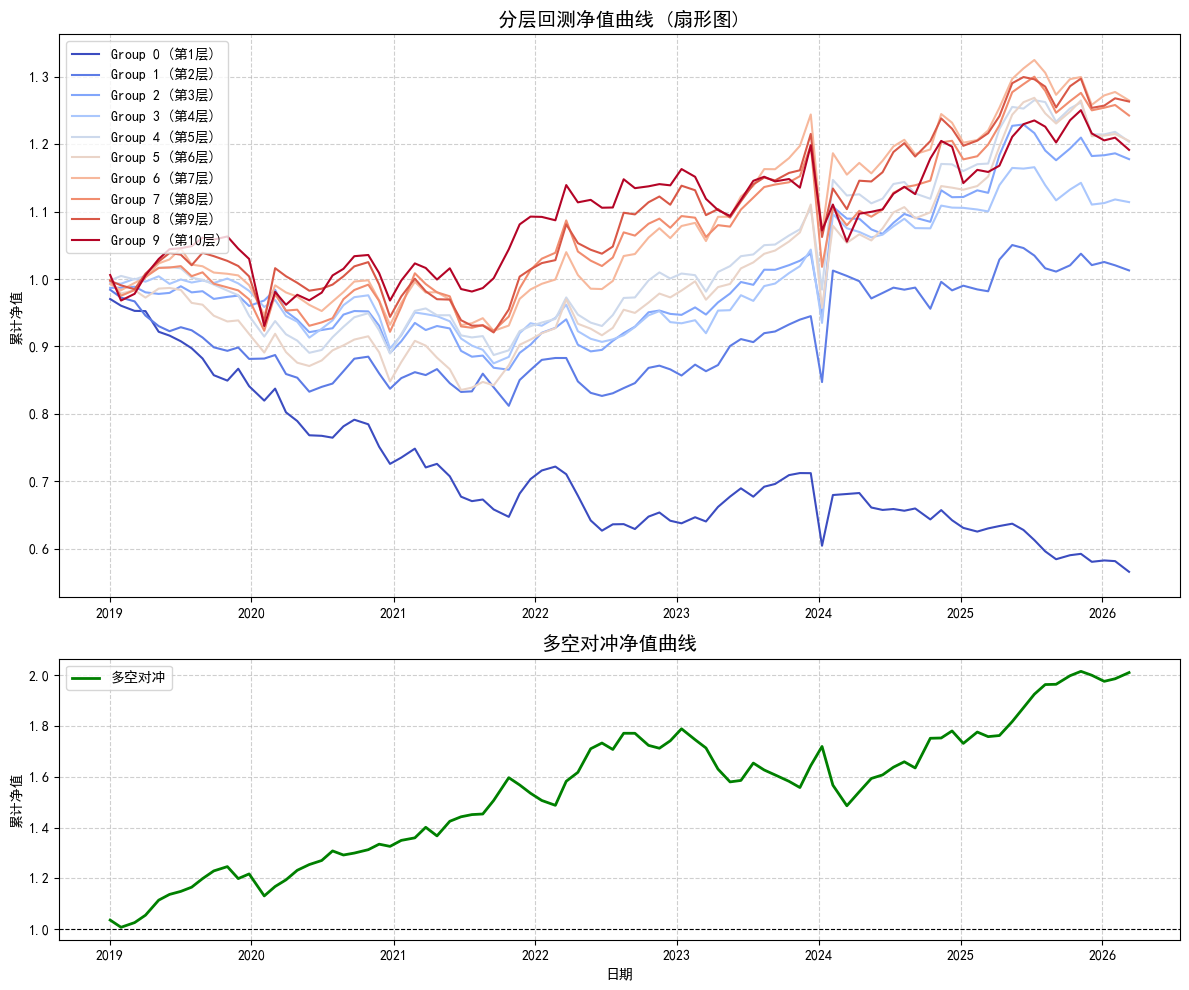

In [96]:
n=10
all_sample['group'] = all_sample.groupby('trade_date')['rsrs'].transform(
    lambda x: pd.qcut(x.rank(method='first'), n, labels=False, duplicates='drop'))
# 2. 计算每组每日的等权平均收益
# Group 0 是预测最差的组，Group n_groups-1 是预测最好的组
group_ret = all_sample.groupby(['trade_date', 'group'])['20d_excess_returns'].mean().unstack()
# 3. 处理换仓成本 (简化处理：假设每组每期全额换仓，扣除双边成本)
group_ret = group_ret - 2 * 0.0015
# 4. 计算多空对冲收益 (做多最好组，做空最差组)
group_ret['Long_Short'] = group_ret[n - 1] - group_ret[0]
# 5. 计算累计净值
group_nav = (1 + group_ret.iloc[::20]).cumprod()

# 绘图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})
# 子图1：各组净值曲线 (扇形图)
n_groups = len(group_nav.columns) - 1 # 减去 Long_Short 列
colors = plt.cm.coolwarm(np.linspace(0, 1, n_groups))
for i in range(0, n_groups, 1):
    axes[0].plot(group_nav.index, group_nav[i], label=f'Group {i} (第{i+1}层)', color=colors[i], linewidth=1.5)
axes[0].set_title('分层回测净值曲线 (扇形图)', fontsize=14)
axes[0].set_ylabel('累计净值')
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.6)
# 子图2：多空对冲净值曲线
axes[1].plot(group_nav.index, group_nav['Long_Short'], label='多空对冲', color='green', linewidth=2)
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('多空对冲净值曲线', fontsize=14)
axes[1].set_xlabel('日期')
axes[1].set_ylabel('累计净值')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()